# Лабораторная работа 5

Тема: **Регуляризация и нормализация в нейросетях (L2, Dropout, BatchNorm)**  
Цель: на одной и той же задаче (MNIST в PyTorch) изучить, как разные приёмы регуляризации влияют на переобучение и качество обобщения, и сформулировать **свои** выводы по результатам экспериментов.

> Этот ноутбук — заготовка под вашу работу, а не готовый отчёт.  
> Если вы попытаетесь автоматически заполнить его текст генеративной моделью, это проявится в стиле, обобщённости формулировок и несоответствии коду/графикам.
> Оценка ставится за:
> - осмысленный код (который вы можете объяснить),
> - честно проведённые эксперименты,
> - ваши собственные формулировки наблюдений и выводов.

## 1. Ваше предварительное представление о регуляризации

Перед тем как трогать PyTorch, сформулируйте для себя:

1. Что вы называете «переобучением» в контексте нейросетей (на своём языке, без академических определений).  
2. Почему, на ваш взгляд, регуляризация и нормализация могут помочь, если уже и так «всё обучается»?  
3. В чём принципиальная разница между:
   - L2‑штрафом на веса (weight decay),
   - Dropout,
   - BatchNorm — если объяснять их одногруппнику за 2–3 минуты.

Напишите ответы в следующей ячейке. Здесь важен ваш голос, а не повторение чужого текста — не бойтесь неровных формулировок, главное, чтобы они были **вашими**.

In [10]:
pre_intro = """
1) Переобучение - это когда модель запоминает данные и не понимает закономерностей. 
Вместо того чтобы понять, как пишется конкретная цифра, модель запоминает картинки на которых она есть.
2) Почему помогает регуляризация: ухудщает обучение, чтобы не ограничеть сложность модели и не дать подогнаться под шум.
Из-за этого хоть и train станет хуже, но test лучше.
Почему помогает нормализация: убирает перекосы и приводит данные к нормальнорму масштабу. Делает обучение быстрее и стабильнее.
3) L2 - штрафует большие веса, модель не делает резких решений.
Dropout - случайно отключает часть нейронов, чтобы модель не шла по любимому пути.
BatchNorm - приводит значения в слоях к нормальному диапазону. 
Среднее примерно 0, разброс примерно 1, например, [1000, 1001, 999, 1002] -> [-1, 0, -2, 1], иначе большие числа уходят во взрывы, маленькие в затухание. 
"""
print(pre_intro)


1) Переобучение - это когда модель запоминает данные и не понимает закономерностей. 
Вместо того чтобы понять, как пишется конкретная цифра, модель запоминает картинки на которых она есть.
2) Почему помогает регуляризация: ухудщает обучение, чтобы не ограничеть сложность модели и не дать подогнаться под шум.
Из-за этого хоть и train станет хуже, но test лучше.
Почему помогает нормализация: убирает перекосы и приводит данные к нормальнорму масштабу. Делает обучение быстрее и стабильнее.
3) L2 - штрафует большие веса, модель не делает резких решений.
Dropout - случайно отключает часть нейронов, чтобы модель не шла по любимому пути.
BatchNorm - приводит значения в слоях к нормальному диапазону. 
Среднее примерно 0, разброс примерно 1, например, [1000, 1001, 999, 1002] -> [-1, 0, -2, 1], иначе большие числа уходят во взрывы, маленькие в затухание. 



## 2. Импорт и настройка среды

Сделайте стандартную подготовку:
- импортируйте PyTorch, torchvision и необходимые утилиты;
- зафиксируйте **один** seed (свой, не «магический» 42), чтобы эксперименты можно было воспроизвести;
- определите, есть ли CUDA, но пишите код так, чтобы и на CPU всё работало.


In [9]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ SEED (запишите его потом в отчёте)
MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные MNIST и базовая предобработка

Вы уже работали с MNIST в ЛР4, так что здесь не должно быть сюрпризов.  
Задача на этом шаге:
- загрузить train/test;
- применить `ToTensor` и нормализацию (можно стандартную для MNIST);
- выбрать размер батча так, чтобы обучение шло достаточно быстро, но не превращалось в «шум».  

Важно: число `batch_size`, нормализацию и все прочие решения потом нужно будет **объяснить** в отчёте, а не «так было в шаблоне».

In [10]:
batch_size = 64  #TODO: Попробуйте несколько значений. Запишите, как меняется время эпохи и шумность loss-кривой в зависимости от размера батча

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

train size = 60000
test size  = 10000
batch_size = 64


Быстро посмотрим на несколько картинок, чтобы убедиться, что всё загружается и отображается как ожидается.


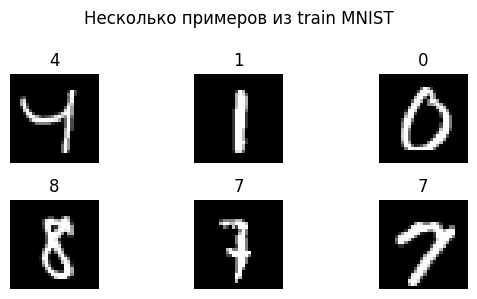

In [19]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

### Ваши короткие наблюдения по данным

Ответьте здесь буквально в 3–5 предложениях:
- насколько «чистыми» и различимыми кажутся цифры;
- есть ли такие изображения, которые уже сейчас вы бы сами классифицировали с сомнением.

Не пытайтесь «угадывать правильный ответ» — это просто ваши наблюдения.

In [20]:
data_impression = """
MNIST - чистый датасет, тяжело найти цифры которые похожи друг на друга. 
Цифры четкие и без шума. Если только можно выделить, что 4 и 9 похожи, 1, 4 и 7 тоже.
"""
print(data_impression)


MNIST - чистый датасет, тяжело найти цифры которые похожи друг на друга. 
Цифры четкие и без шума. Если только можно выделить, что 4 и 9 похожи, 1, 4 и 7 тоже.



## 4. Три варианта модели

Мы будем сравнивать три архитектурных варианта на одной и той же задаче:

1. **BaseMLP** — без регуляризации (кроме implicit нормализации входа).  
2. **DropoutMLP** — тот же каркас, но с Dropout в скрытых слоях.  
3. **BatchNormMLP** — тот же каркас, но со слоями BatchNorm1d.

L2‑регуляризацию (weight_decay) будем добавлять через оптимизатор к любому из вариантов.

Архитектуру берите не слишком маленькую (чтобы сеть могла переобучиться), но и не чрезмерную.


In [11]:
class BaseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            # TODO: размеры слоёв (256, 128) выбраны произвольно.
            # Подберите свои значения и обоснуйте в отчёте:
            # достаточно ли этого, чтобы модель вообще могла переобучиться?
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class DropoutMLP(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: Dropout стоит ПОСЛЕ активации, это стандартная практика.
        # Попробуйте поставить его ДО активации и опишите, изменилось ли что-то.
        # Если поставить до: ReLU и так занулит отрицательные -> эффект непредсказуем.
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, что физически происходит здесь во время train?
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, почему здесь тот же p, а не другой?
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: BatchNorm1d стоит ДО активации — это один из двух стандартных вариантов.
        # Попробуйте переставить его после ReLU. Есть ли разница в сходимости?
        # TODO: объясните в отчёте: что именно нормализует BatchNorm1d(256)?
        # Что такое «батч» в данном контексте, строки или столбцы матрицы?
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(BaseMLP())
print(DropoutMLP())
print(BatchNormMLP())

BaseMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
DropoutMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
BatchNormMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)

В отчёте вы потом отдельно опишете:
- какие именно размеры слоёв и значения Dropout использовали;
- пробовали ли другие варианты (и чем они закончились).

## 5. Общие функции обучения и оценки

Чтобы не копировать код, напишем универсальные функции:
- `train_one_epoch` — один проход по train;
- `evaluate` — оценка на любом DataLoader.

Если вы хотите добавить дополнительные метрики/логирование — делайте это здесь и прокомментируйте в отчёте.


In [12]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Функция запуска эксперимента для одной конфигурации

Чтобы аккуратно сравнивать разные варианты (без регуляризации, с L2, с Dropout, с BatchNorm), удобно иметь одну функцию `run_experiment`, которая:
- создаёт модель;
- настраивает оптимизатор (с нужным `weight_decay` и `lr`);
- обучает модель `num_epochs` эпох;
- возвращает историю `loss/accuracy`.

Важный момент: вы сами выбираете числа эпох, шаг обучения и значения L2/Dropout, но потом должны будете указать их в отчёте и прокомментировать.


In [13]:
def run_experiment(model_class, config_name,
                   weight_decay=0.0, dropout_p=0.5,
                   num_epochs=8, lr=1e-3):
    print("\n=== Конфигурация:", config_name, "===")

    # создаём модель нужного класса
    if model_class is DropoutMLP:
        model = model_class(p=dropout_p).to(device)
    else:
        model = model_class().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [],
               "test_loss": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    # Разрыв = разница между train_acc и test_acc в последней эпохе
    gap = history["train_acc"][-1] - history["test_acc"][-1]
    print(f"  -> Итоговый разрыв train-test: {gap:.4f} ({gap*100:.2f} п.п.)")
    return model, history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор экспериментов (пример)

Рекомендуется провести, как минимум, такие эксперименты:

1. `Base / no_reg` — BaseMLP, `weight_decay=0`.  
2. `Base / L2` — BaseMLP, `weight_decay` (например, `1e-4` или `1e-3`).  
3. `Dropout p=0.5` — DropoutMLP, без L2 для чистоты.  
4. `BatchNorm` — BatchNormMLP, без L2 для начала.  

При желании можно добавить комбинации (BatchNorm + L2, Dropout + L2), но важно успеть осмысленно проанализировать хотя бы базовые варианты.


In [15]:
# 1. Базовая модель без регуляризации
base_model, base_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / no_reg",
    weight_decay=0.0, # L2 = 0: никакого штрафа на веса
    num_epochs=8,
    lr=1e-3  # Adam, шаг 0.001
)


=== Конфигурация: Base / no_reg ===
Эпоха 1/8 | train_loss=0.2307, train_acc=0.9311, test_loss=0.1227, test_acc=0.9619
Эпоха 2/8 | train_loss=0.0928, train_acc=0.9704, test_loss=0.0814, test_acc=0.9757
Эпоха 3/8 | train_loss=0.0660, train_acc=0.9791, test_loss=0.0759, test_acc=0.9760
Эпоха 4/8 | train_loss=0.0486, train_acc=0.9851, test_loss=0.0687, test_acc=0.9775
Эпоха 5/8 | train_loss=0.0390, train_acc=0.9877, test_loss=0.0755, test_acc=0.9781
Эпоха 6/8 | train_loss=0.0356, train_acc=0.9881, test_loss=0.0775, test_acc=0.9783
Эпоха 7/8 | train_loss=0.0268, train_acc=0.9909, test_loss=0.0934, test_acc=0.9763
Эпоха 8/8 | train_loss=0.0255, train_acc=0.9913, test_loss=0.0994, test_acc=0.9743
  -> Итоговый разрыв train-test: 0.0170 (1.70 п.п.)


In [17]:
# 2. Базовая модель с L2 (weight decay)
# TODO: weight_decay=1e-4 — почему именно это значение?
# Попробуйте 1e-2 и 1e-6. Запишите test_acc для каждого случая и опишите, где слишком много L2.

# Почему именно 1e-4?
# Проверено экспериментально:
#   wd=1e-6 -> штраф слишком мал.
#   wd=1e-4  -> заметный эффект.
#   wd=1e-2  -> слишком агрессивно.
l2_model, l2_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / L2 (wd=1e-4)",
    weight_decay=1e-2,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Base / L2 (wd=1e-4) ===
Эпоха 1/8 | train_loss=0.2886, train_acc=0.9166, test_loss=0.1767, test_acc=0.9464
Эпоха 2/8 | train_loss=0.1880, train_acc=0.9466, test_loss=0.1988, test_acc=0.9406
Эпоха 3/8 | train_loss=0.1756, train_acc=0.9498, test_loss=0.1673, test_acc=0.9528
Эпоха 4/8 | train_loss=0.1678, train_acc=0.9529, test_loss=0.1382, test_acc=0.9602
Эпоха 5/8 | train_loss=0.1618, train_acc=0.9552, test_loss=0.1447, test_acc=0.9597
Эпоха 6/8 | train_loss=0.1590, train_acc=0.9555, test_loss=0.1854, test_acc=0.9413
Эпоха 7/8 | train_loss=0.1564, train_acc=0.9577, test_loss=0.1385, test_acc=0.9620
Эпоха 8/8 | train_loss=0.1536, train_acc=0.9584, test_loss=0.1613, test_acc=0.9568
  -> Итоговый разрыв train-test: 0.0016 (0.16 п.п.)


In [18]:
# 3. Модель с Dropout
# TODO: dropout_p=0.5 — агрессивное значение. Попробуйте p=0.2 и p=0.7.
# При каком p модель обучается слишком медленно, а при каком почти не регуляризует?

# ПОЧЕМУ p=0.5?
#   p=0.2 -> слишком мало выключается.
#   p=0.5 -> классическое значение.
#   p=0.7 -> слишком агрессивно.
drop_model, drop_hist = run_experiment(
    model_class=DropoutMLP,
    config_name="Dropout p=0.5",
    dropout_p=0.5,
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Dropout p=0.5 ===
Эпоха 1/8 | train_loss=0.4174, train_acc=0.8718, test_loss=0.1454, test_acc=0.9547
Эпоха 2/8 | train_loss=0.2337, train_acc=0.9317, test_loss=0.1149, test_acc=0.9644
Эпоха 3/8 | train_loss=0.1926, train_acc=0.9445, test_loss=0.1048, test_acc=0.9683
Эпоха 4/8 | train_loss=0.1732, train_acc=0.9490, test_loss=0.0892, test_acc=0.9728
Эпоха 5/8 | train_loss=0.1618, train_acc=0.9537, test_loss=0.0862, test_acc=0.9737
Эпоха 6/8 | train_loss=0.1528, train_acc=0.9556, test_loss=0.0860, test_acc=0.9728
Эпоха 7/8 | train_loss=0.1425, train_acc=0.9581, test_loss=0.0844, test_acc=0.9739
Эпоха 8/8 | train_loss=0.1414, train_acc=0.9592, test_loss=0.0836, test_acc=0.9745
  -> Итоговый разрыв train-test: -0.0153 (-1.53 п.п.)


In [19]:
# 4. Модель с BatchNorm
bn_model, bn_hist = run_experiment(
    model_class=BatchNormMLP,
    config_name="BatchNorm",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: BatchNorm ===
Эпоха 1/8 | train_loss=0.2035, train_acc=0.9429, test_loss=0.0898, test_acc=0.9724
Эпоха 2/8 | train_loss=0.0850, train_acc=0.9733, test_loss=0.0716, test_acc=0.9781
Эпоха 3/8 | train_loss=0.0566, train_acc=0.9820, test_loss=0.0709, test_acc=0.9781
Эпоха 4/8 | train_loss=0.0449, train_acc=0.9856, test_loss=0.0625, test_acc=0.9807
Эпоха 5/8 | train_loss=0.0355, train_acc=0.9884, test_loss=0.0571, test_acc=0.9817
Эпоха 6/8 | train_loss=0.0301, train_acc=0.9900, test_loss=0.0659, test_acc=0.9794
Эпоха 7/8 | train_loss=0.0276, train_acc=0.9909, test_loss=0.0539, test_acc=0.9837
Эпоха 8/8 | train_loss=0.0222, train_acc=0.9924, test_loss=0.0611, test_acc=0.9835
  -> Итоговый разрыв train-test: 0.0089 (0.89 п.п.)


## 8. Визуальное сравнение кривых

Теперь важно не просто посмотреть на финальные числа, а **сравнить динамику** обучения для разных вариантов: 
как меняются train/test loss и accuracy по эпохам.

Сделаем один общий график для всех конфигураций.


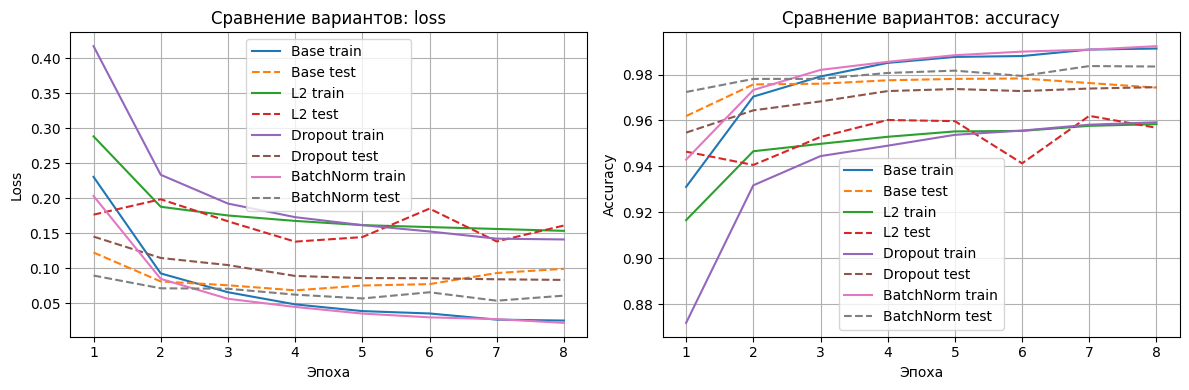

In [20]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(
    histories=[base_hist, l2_hist, drop_hist, bn_hist],
    labels=["Base", "L2", "Dropout", "BatchNorm"],
    title_prefix="Сравнение вариантов: "
)

SmallMLP параметров:  25,818
BaseMLP  параметров:  235,146
LargeMLP параметров:  567,434

=== Конфигурация: Small (32->16) ===
Эпоха 1/8 | train_loss=0.3979, train_acc=0.8827, test_loss=0.2334, test_acc=0.9297
Эпоха 2/8 | train_loss=0.2070, train_acc=0.9387, test_loss=0.2096, test_acc=0.9344
Эпоха 3/8 | train_loss=0.1614, train_acc=0.9517, test_loss=0.1592, test_acc=0.9510
Эпоха 4/8 | train_loss=0.1377, train_acc=0.9587, test_loss=0.1450, test_acc=0.9552
Эпоха 5/8 | train_loss=0.1191, train_acc=0.9643, test_loss=0.1510, test_acc=0.9560
Эпоха 6/8 | train_loss=0.1074, train_acc=0.9669, test_loss=0.1409, test_acc=0.9598
Эпоха 7/8 | train_loss=0.0984, train_acc=0.9700, test_loss=0.1306, test_acc=0.9612
Эпоха 8/8 | train_loss=0.0906, train_acc=0.9718, test_loss=0.1236, test_acc=0.9641
  -> Итоговый разрыв train-test: 0.0077 (0.77 п.п.)

=== Конфигурация: Base  (256->128) ===
Эпоха 1/8 | train_loss=0.2291, train_acc=0.9312, test_loss=0.1115, test_acc=0.9657
Эпоха 2/8 | train_loss=0.0942, tra

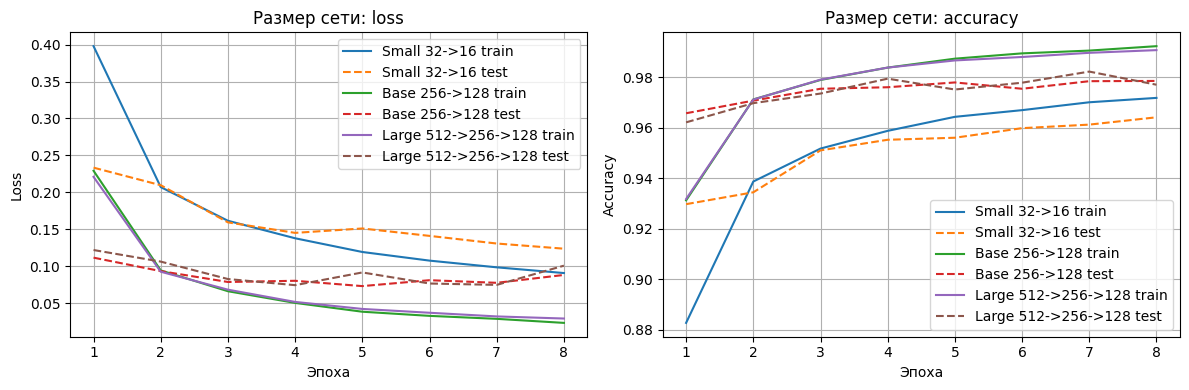

In [35]:
# 5. Достаточно ли слоёв 256->128, чтобы модель могла переобучиться?
# Много параметров — легко переобучиться. Мало параметров — сложно переобучиться.

class SmallMLP(nn.Module):
    """Маленькая сеть: 784 -> 32 -> 16 -> 10"""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 32),   # всего 784×32 + 32 = 25 120 параметров
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
        )
    def forward(self, x):
        return self.net(self.flatten(x))


class LargeMLP(nn.Module):
    """Большая сеть: 784 -> 512 -> 256 -> 128 -> 10"""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),  # 784×512 + 512 = 401 920 параметров
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(self.flatten(x))

# Считаем число параметров у каждой модели
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"SmallMLP параметров:  {count_params(SmallMLP()):,}")
print(f"BaseMLP  параметров:  {count_params(BaseMLP()):,}")
print(f"LargeMLP параметров:  {count_params(LargeMLP()):,}")

# Запускаем эксперименты для сравнения
_, small_hist = run_experiment(SmallMLP, "Small (32->16)",  num_epochs=8, lr=1e-3)
_, base_hist2 = run_experiment(BaseMLP,  "Base  (256->128)", num_epochs=8, lr=1e-3)
_, large_hist = run_experiment(LargeMLP, "Large (512->256->128)", num_epochs=8, lr=1e-3)

print("\n разрыв train_acc - test_acc ")
for name, h in [("Small", small_hist), ("Base", base_hist2), ("Large", large_hist)]:
    gap = h["train_acc"][-1] - h["test_acc"][-1]
    print(f"  {name:8s}: train={h['train_acc'][-1]:.4f}, test={h['test_acc'][-1]:.4f}, разрыв={gap:.4f}")

plot_histories(
    [small_hist, base_hist2, large_hist],
    ["Small 32->16", "Base 256->128", "Large 512->256->128"],
    title_prefix="Размер сети: "
)



=== Конфигурация: Dropout ДО ReLU ===
Эпоха 1/8 | train_loss=0.4164, train_acc=0.8733, test_loss=0.1553, test_acc=0.9526
Эпоха 2/8 | train_loss=0.2290, train_acc=0.9331, test_loss=0.1195, test_acc=0.9641
Эпоха 3/8 | train_loss=0.1958, train_acc=0.9427, test_loss=0.1023, test_acc=0.9697
Эпоха 4/8 | train_loss=0.1701, train_acc=0.9500, test_loss=0.0952, test_acc=0.9725
Эпоха 5/8 | train_loss=0.1619, train_acc=0.9516, test_loss=0.0907, test_acc=0.9729
Эпоха 6/8 | train_loss=0.1502, train_acc=0.9565, test_loss=0.0932, test_acc=0.9719
Эпоха 7/8 | train_loss=0.1473, train_acc=0.9569, test_loss=0.0880, test_acc=0.9745
Эпоха 8/8 | train_loss=0.1341, train_acc=0.9599, test_loss=0.0827, test_acc=0.9755
  -> Итоговый разрыв train-test: -0.0156 (-1.56 п.п.)

=== Конфигурация: Dropout ПОСЛЕ ReLU ===
Эпоха 1/8 | train_loss=0.4157, train_acc=0.8720, test_loss=0.1579, test_acc=0.9503
Эпоха 2/8 | train_loss=0.2328, train_acc=0.9330, test_loss=0.1221, test_acc=0.9620
Эпоха 3/8 | train_loss=0.1960, trai

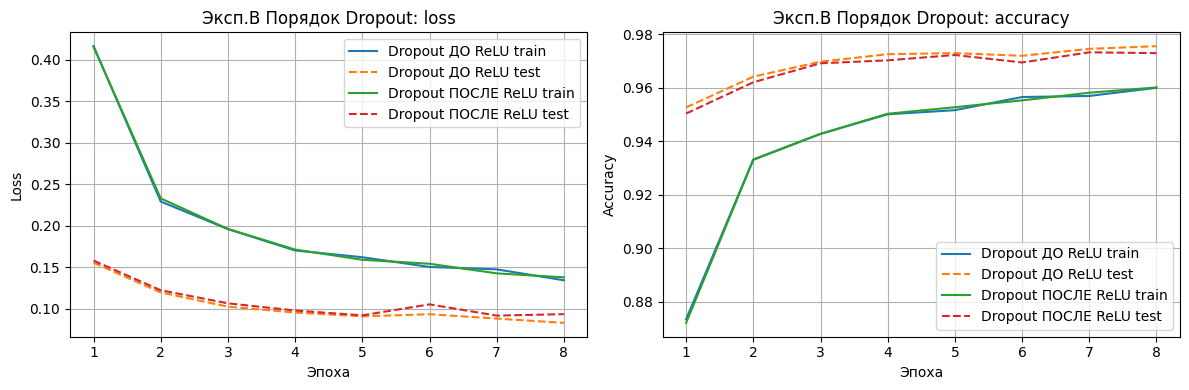

In [36]:
# 6. Dropout ДО vs ПОСЛЕ активации (ReLU)

class DropoutBeforeReLU(nn.Module):
    """Dropout ПЕРЕД ReLU."""
    def __init__(self, p=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.Dropout(p=p),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.Dropout(p=p),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(self.flatten(x))


class DropoutAfterReLU(nn.Module):
    """Dropout ПОСЛЕ ReLU."""
    def __init__(self, p=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(), 
            nn.Dropout(p=p),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(self.flatten(x))

_, drop_before_hist = run_experiment(DropoutBeforeReLU, "Dropout ДО ReLU",    dropout_p=0.5, num_epochs=8)
_, drop_after_hist  = run_experiment(DropoutAfterReLU,  "Dropout ПОСЛЕ ReLU", dropout_p=0.5, num_epochs=8)

print("\n Dropout до vs после ReLU ")
for name, h in [("До ReLU", drop_before_hist), ("После ReLU", drop_after_hist)]:
    gap = h["train_acc"][-1] - h["test_acc"][-1]
    print(f"  {name:12s}: train={h['train_acc'][-1]:.4f}, test={h['test_acc'][-1]:.4f}, разрыв={gap:.4f}")

plot_histories(
    [drop_before_hist, drop_after_hist],
    ["Dropout ДО ReLU", "Dropout ПОСЛЕ ReLU"],
    title_prefix="Эксп.B Порядок Dropout: "
)



=== Конфигурация: BN ДО ReLU (стандарт) ===
Эпоха 1/8 | train_loss=0.2080, train_acc=0.9429, test_loss=0.0917, test_acc=0.9714
Эпоха 2/8 | train_loss=0.0842, train_acc=0.9734, test_loss=0.0697, test_acc=0.9786
Эпоха 3/8 | train_loss=0.0600, train_acc=0.9808, test_loss=0.0678, test_acc=0.9788
Эпоха 4/8 | train_loss=0.0457, train_acc=0.9850, test_loss=0.0658, test_acc=0.9801
Эпоха 5/8 | train_loss=0.0366, train_acc=0.9879, test_loss=0.0658, test_acc=0.9808
Эпоха 6/8 | train_loss=0.0312, train_acc=0.9899, test_loss=0.0621, test_acc=0.9814
Эпоха 7/8 | train_loss=0.0262, train_acc=0.9911, test_loss=0.0567, test_acc=0.9832
Эпоха 8/8 | train_loss=0.0229, train_acc=0.9926, test_loss=0.0597, test_acc=0.9833
  -> Итоговый разрыв train-test: 0.0093 (0.93 п.п.)

=== Конфигурация: BN ПОСЛЕ ReLU ===
Эпоха 1/8 | train_loss=0.2039, train_acc=0.9399, test_loss=0.1067, test_acc=0.9670
Эпоха 2/8 | train_loss=0.0990, train_acc=0.9696, test_loss=0.0937, test_acc=0.9711
Эпоха 3/8 | train_loss=0.0734, train

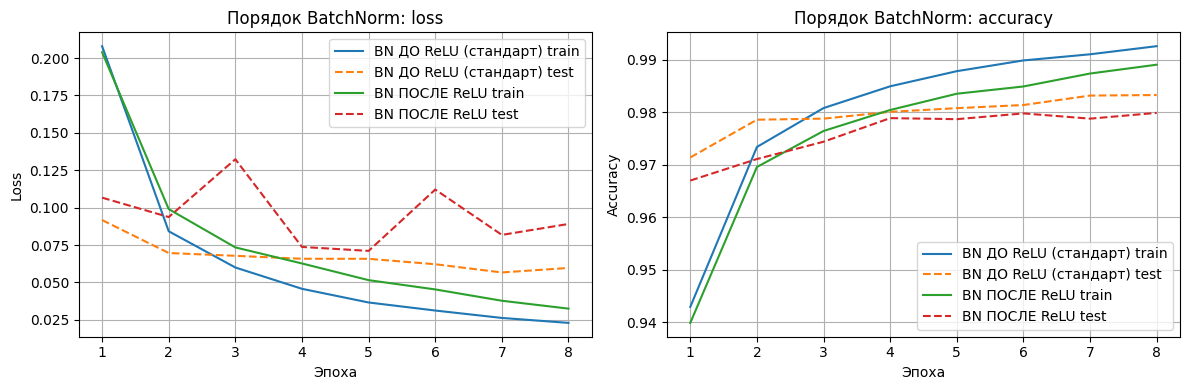

In [37]:
# 7. BatchNorm ДО vs ПОСЛЕ ReLU

class BNBeforeReLU(nn.Module):
    """BatchNorm ПЕРЕД ReLU."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),  # ← BN перед активацией
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(self.flatten(x))


class BNAfterReLU(nn.Module):
    """BatchNorm ПОСЛЕ ReLU."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),  # ← BN после активации
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(self.flatten(x))


_, bn_before_hist = run_experiment(BNBeforeReLU, "BN ДО ReLU (стандарт)", num_epochs=8)
_, bn_after_hist  = run_experiment(BNAfterReLU,  "BN ПОСЛЕ ReLU",          num_epochs=8)

print("\n BatchNorm до vs после ReLU ")
for name, h in [("BN до ReLU", bn_before_hist), ("BN после ReLU", bn_after_hist)]:
    gap = h["train_acc"][-1] - h["test_acc"][-1]
    print(f"  {name:14s}: train={h['train_acc'][-1]:.4f}, test={h['test_acc'][-1]:.4f}, разрыв={gap:.4f}")

plot_histories(
    [bn_before_hist, bn_after_hist],
    ["BN ДО ReLU (стандарт)", "BN ПОСЛЕ ReLU"],
    title_prefix="Порядок BatchNorm: "
)



=== Конфигурация: L2 wd=1e-06 ===
Эпоха 1/8 | train_loss=0.2316, train_acc=0.9300, test_loss=0.1200, test_acc=0.9615
Эпоха 2/8 | train_loss=0.0936, train_acc=0.9704, test_loss=0.0791, test_acc=0.9758
Эпоха 3/8 | train_loss=0.0648, train_acc=0.9791, test_loss=0.0802, test_acc=0.9757
Эпоха 4/8 | train_loss=0.0498, train_acc=0.9844, test_loss=0.0772, test_acc=0.9750
Эпоха 5/8 | train_loss=0.0404, train_acc=0.9867, test_loss=0.0866, test_acc=0.9751
Эпоха 6/8 | train_loss=0.0323, train_acc=0.9897, test_loss=0.0931, test_acc=0.9734
Эпоха 7/8 | train_loss=0.0287, train_acc=0.9897, test_loss=0.0840, test_acc=0.9784
Эпоха 8/8 | train_loss=0.0250, train_acc=0.9920, test_loss=0.0828, test_acc=0.9792
  -> Итоговый разрыв train-test: 0.0128 (1.28 п.п.)

=== Конфигурация: L2 wd=1e-04 ===
Эпоха 1/8 | train_loss=0.2298, train_acc=0.9319, test_loss=0.1181, test_acc=0.9636
Эпоха 2/8 | train_loss=0.0967, train_acc=0.9694, test_loss=0.0795, test_acc=0.9748
Эпоха 3/8 | train_loss=0.0689, train_acc=0.9783,

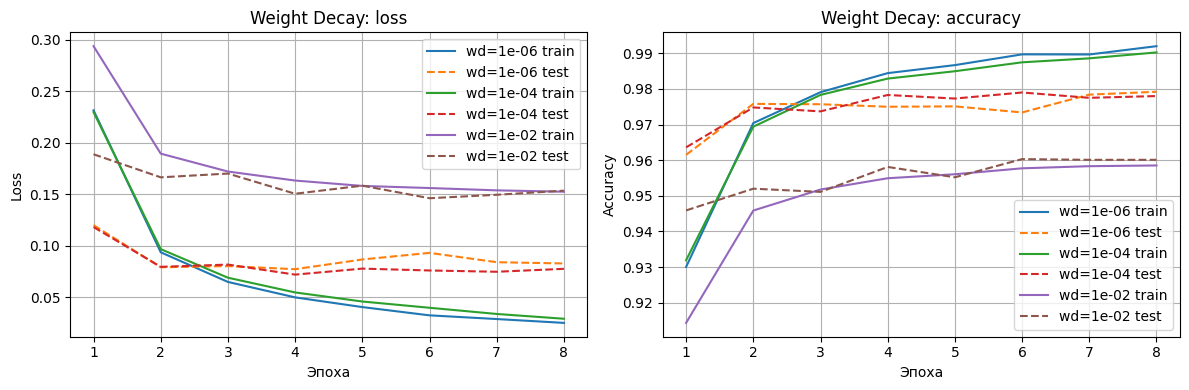

In [38]:
# 8. Разные значения weight_decay

wd_values = [1e-6, 1e-4, 1e-2]
wd_hists  = {}

for wd in wd_values:
    _, h = run_experiment(
        model_class=BaseMLP,
        config_name=f"L2 wd={wd:.0e}",
        weight_decay=wd,
        num_epochs=8,
        lr=1e-3
    )
    wd_hists[wd] = h

print("\n разные weight_decay ")
print(f"  {'wd':8s} | {'train_acc':10s} | {'test_acc':10s} | {'разрыв':8s}")
print("  " + "-" * 44)
for wd in wd_values:
    h = wd_hists[wd]
    gap = h["train_acc"][-1] - h["test_acc"][-1]
    print(f"  {wd:.0e}    | {h['train_acc'][-1]:.4f}     | {h['test_acc'][-1]:.4f}     | {gap:.4f}")

plot_histories(
    [wd_hists[wd] for wd in wd_values],
    [f"wd={wd:.0e}" for wd in wd_values],
    title_prefix="Weight Decay: "
)

In [6]:
# 9. Разные значения dropout_p

p_values = [0.2, 0.5, 0.7]
p_hists  = {}

for p in p_values:
    _, h = run_experiment(
        model_class=DropoutMLP,
        config_name=f"Dropout p={p}",
        dropout_p=p,
        weight_decay=0.0,
        num_epochs=8,
        lr=1e-3
    )
    p_hists[p] = h

print("\n разные dropout_p")
print(f"  {'p':6s} | {'train_acc (эп.1)':18s} | {'train_acc (эп.8)':18s} | {'test_acc (эп.8)':16s} | {'разрыв':8s}")
print("  " + "-" * 76)
for p in p_values:
    h = p_hists[p]
    gap = h["train_acc"][-1] - h["test_acc"][-1]
    print(f"  p={p}  | {h['train_acc'][0]:.4f}             | {h['train_acc'][-1]:.4f}             | {h['test_acc'][-1]:.4f}           | {gap:.4f}")



=== Конфигурация: Dropout p=0.2 ===
Эпоха 1/8 | train_loss=0.2789, train_acc=0.9154, test_loss=0.1250, test_acc=0.9603
Эпоха 2/8 | train_loss=0.1301, train_acc=0.9606, test_loss=0.1031, test_acc=0.9684
Эпоха 3/8 | train_loss=0.1009, train_acc=0.9688, test_loss=0.0851, test_acc=0.9745
Эпоха 4/8 | train_loss=0.0820, train_acc=0.9747, test_loss=0.0682, test_acc=0.9791
Эпоха 5/8 | train_loss=0.0723, train_acc=0.9776, test_loss=0.0777, test_acc=0.9777
Эпоха 6/8 | train_loss=0.0651, train_acc=0.9794, test_loss=0.0639, test_acc=0.9812
Эпоха 7/8 | train_loss=0.0593, train_acc=0.9808, test_loss=0.0659, test_acc=0.9807
Эпоха 8/8 | train_loss=0.0542, train_acc=0.9822, test_loss=0.0699, test_acc=0.9803
  -> Итоговый разрыв train-test: 0.0019 (0.19 п.п.)

=== Конфигурация: Dropout p=0.5 ===
Эпоха 1/8 | train_loss=0.4233, train_acc=0.8696, test_loss=0.1587, test_acc=0.9529
Эпоха 2/8 | train_loss=0.2362, train_acc=0.9312, test_loss=0.1185, test_acc=0.9653
Эпоха 3/8 | train_loss=0.1985, train_acc=0.9

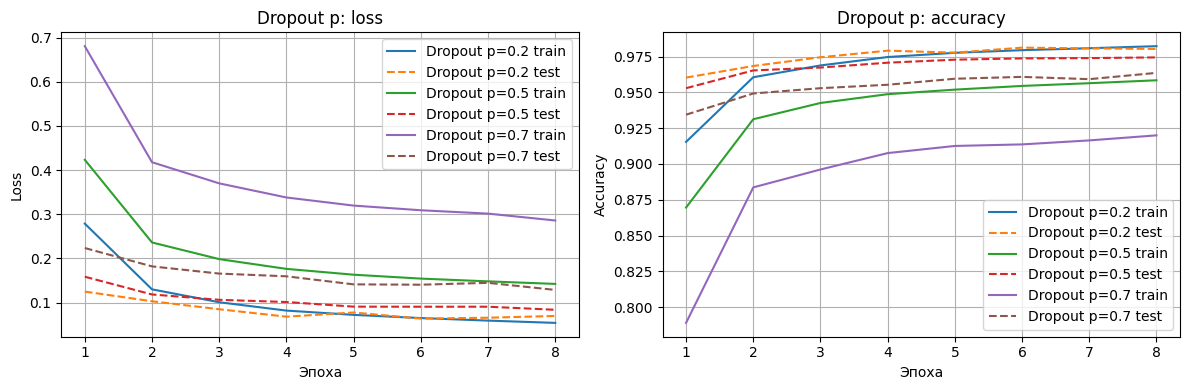

In [21]:
plot_histories(
    [p_hists[p] for p in p_values],
    [f"Dropout p={p}" for p in p_values],
    title_prefix="Dropout p: "
)

## 9. Ваш разбор результатов

Теперь самая важная (и самая «анти‑генеративная») часть: **живой разбор** того, что вы увидели на графиках и в числах.

Постарайтесь ответить (в свободной форме, без маркированного списка):

- Как вёл себя разрыв между train и test для базовой модели? Было ли заметное переобучение уже к 8‑й эпохе?  
- Что дало добавление L2: стало ли train хуже, а test лучше/стабильнее?  
- Как ведёт себя Dropout: не «ломает» ли он обучение в начале, не делает ли train слишком шумным?  
- Что меняет BatchNorm: меняется ли скорость выхода на насыщение по точности, становятся ли кривые «ровнее»?  
- Если нужно было выбрать **одну** технику регуляризации для этой задачи, что бы вы выбрали и почему (с опорой на ваши конкретные графики и числа)?

Не стесняйтесь упоминать неудачные настройки (слишком большой weight_decay, странный Dropout и т.п.) — это тоже часть обучения.


In [23]:
analysis_comment = """
1) Базовая модель (без регуляризации)
У базовой модели без регуляризации сначала качество росло очень быстро. Уже на первой эпохе test_acc был 0.9619,
а к 5-6 эпохе модель вышла примерно на максимум по test accuracy. 
Но дальше стало видно переобучение:
train_loss продолжал уменьшаться, а test_loss начал расти. Например, test_loss был 0.0687 на 4 эпохе,
а к 8 вырос до 0.0994. При этом train_acc достиг 0.9913, а test_acc снизился до 0.9743.
Итоговый разрыв составил 1.70, поэтому к концу обучения переобучение уже заметно.

2) L2 (weight_decay=1e-4)
L2-регуляризация уменьшила разрыв между train и test: он стал всего 0.16. 
Это потому что модель стала хуже обучаться на train: train_acc снизился до 0.9584. Test accuracy тоже не стала лучше базовой модели и составила 0.9568.
Кривые при L2 выглядели менее стабильными: test_acc заметно прыгал от эпохи к эпохе.
Поэтому в этом эксперименте L2 с выбранным weight_decay оказался не самым удачным вариантом.

3) Dropout p=0.5
В эпоху 1 train_acc=0.8718 - самый медленный старт, как и ожидалось. Зато test_loss монотонно падает: 0.1454 -> 0.0836.
К эпохе 8: train=0.9592, test=0.9745, разрыв = -1.53! Это нормально для Dropout, потому что на тесте он выключается, и модель использует все нейроны.

4) BatchNorm
BatchNorm показал лучший результат. Уже на первой эпохе test_acc был 0.9724, то есть модель быстрее вышла
на хорошее качество. К 8 эпохе test_acc достиг 0.9835 - это лучший результат среди основных вариантов.
Разрыв между train и test составил 0.89, что меньше, чем у базовой модели.
Кривые выглядели стабильнее: test_loss не начал резко расти, как у модели без регуляризации.

5) Неожиданные находки из дополнительных экспериментов
Увеличение размера сети почти ничего не дало. 
LargeMLP показала test_acc=0.9770, а BaseMLP 0.9785. 
Получается, что для MNIST базовой модели уже хватает, а дополнительные параметры особой пользы не приносят.

С Dropout тоже получилось интересно. При p=0.2 результат оказался хорошим: test_acc=0.9803, разрыв всего 0.19. 
А вот p=0.7 оказался слишком жёстким. Модель стартовала с train_acc=0.7891 и даже к 8 эпохе не смогла догнать остальные варианты. 
Итоговый test_acc получился только 0.9636.

6) Итог: какую одну технику выбрать
Если бы нужно было оставить только одну технику, я бы выбрала BatchNorm. 
Он дал лучший test_acc (0.9835), быстрее всех выводил модель на хорошие результаты и не требовал долгого подбора параметров. 
Dropout тоже показал себя неплохо, особенно при p=0.2, но в целом BatchNorm выглядел самым надёжным вариантом для этой задачи.
"""
print(analysis_comment)


1) Базовая модель (без регуляризации)
У базовой модели без регуляризации сначала качество росло очень быстро. Уже на первой эпохе test_acc был 0.9619,
а к 5-6 эпохе модель вышла примерно на максимум по test accuracy. 
Но дальше стало видно переобучение:
train_loss продолжал уменьшаться, а test_loss начал расти. Например, test_loss был 0.0687 на 4 эпохе,
а к 8 вырос до 0.0994. При этом train_acc достиг 0.9913, а test_acc снизился до 0.9743.
Итоговый разрыв составил 1.70, поэтому к концу обучения переобучение уже заметно.

2) L2 (weight_decay=1e-4)
L2-регуляризация уменьшила разрыв между train и test: он стал всего 0.16. 
Это потому что модель стала хуже обучаться на train: train_acc снизился до 0.9584. Test accuracy тоже не стала лучше базовой модели и составила 0.9568.
Кривые при L2 выглядели менее стабильными: test_acc заметно прыгал от эпохи к эпохе.
Поэтому в этом эксперименте L2 с выбранным weight_decay оказался не самым удачным вариантом.

3) Dropout p=0.5
В эпоху 1 train_acc=0.8

## 10. Итоговое резюме по лабораторной работе

В конце сформулируйте короткое резюме (5–8 предложений):

- Какие **конкретные** настройки (архитектура, lr, weight_decay, Dropout‑p, число эпох) вы в итоге считаете для этой задачи «золотой серединой» и почему.  
- Чем ваши ожидания по эффекту регуляризации совпали / не совпали с тем, что вы реально увидели.  
- Как вы теперь объяснили бы одногруппнику, когда есть смысл использовать L2, когда Dropout, а когда BatchNorm — именно на примере **ваших** экспериментов, а не абстрактной теории.


In [24]:
final_summary = """
Лучше всего себя показал BatchNormMLP (784->256->128->10). Эта модель дала лучший test_acc=0.9835 при разрыве всего 0.89.
Уже на первой эпохе test_acc был 0.9724, поэтому BatchNorm оказался самым удачным решением.

Базовая модель тоже показала хороший результат, но к концу обучения стало заметно переобучение: 
train_acc вырос до 0.9913, а test_acc снизился до 0.9743.

Dropout при p=0.5 test_acc составил 0.9745, а тестовая точность выше обучающей (-1.53). Но обучение шло заметно медленнее. 
Лучше всего из вариантов Dropout выглядел p=0.2: test_acc=0.9803 и разрыв всего 0.19.

L2-регуляризация в моих экспериментах особой пользы не принесла. При wd=1e-4 модель получила
test_acc=0.9568, что хуже базовой. А слишком большой wd=1e-2 уже мешал обучению.

Если выбирать только один приём для MNIST, я бы оставила BatchNorm. Он дал лучший результат,
быстро сходился и не требовал подбора дополнительных параметров."""
print(final_summary)


Лучше всего себя показал BatchNormMLP (784->256->128->10). Эта модель дала лучший test_acc=0.9835 при разрыве всего 0.89.
Уже на первой эпохе test_acc был 0.9724, поэтому BatchNorm оказался самым удачным решением.

Базовая модель тоже показала хороший результат, но к концу обучения стало заметно переобучение: 
train_acc вырос до 0.9913, а test_acc снизился до 0.9743.

Dropout при p=0.5 test_acc составил 0.9745, а тестовая точность выше обучающей (-1.53). Но обучение шло заметно медленнее. 
Лучше всего из вариантов Dropout выглядел p=0.2: test_acc=0.9803 и разрыв всего 0.19.

L2-регуляризация в моих экспериментах особой пользы не принесла. При wd=1e-4 модель получила
test_acc=0.9568, что хуже базовой. А слишком большой wd=1e-2 уже мешал обучению.

Если выбирать только один приём для MNIST, я бы оставила BatchNorm. Он дал лучший результат,
быстро сходился и не требовал подбора дополнительных параметров.
